# Single-Cell RNA-seq with TMAP

This notebook shows how to use TMAP for single-cell analysis using the PBMC 3k
dataset (the "hello world" of single-cell genomics). We demonstrate:

1. Fitting TMAP on PCA-reduced single-cell data
2. Coloring by cell type and gene expression
3. **Pseudotime** — computing tree distances as a proxy for biological progression
4. Side-by-side comparison with UMAP

**Requirements:** `pip install scanpy tmap`


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

from tmap import TMAP

warnings.filterwarnings("ignore", category=FutureWarning)


## Load the PBMC 3k dataset

Scanpy ships a pre-processed version with PCA, UMAP, and Louvain clusters
already computed. We use the PCA embedding (`adata.obsm['X_pca']`) as input
to TMAP — the same 50-dimensional representation that UMAP consumes.


In [2]:
adata = sc.datasets.pbmc3k_processed()
print(f"Cells: {adata.n_obs}, Genes: {adata.n_vars}")
print(f"PCA shape: {adata.obsm['X_pca'].shape}")
print(f"Cell types: {adata.obs['louvain'].unique().tolist()}")


  0%|          | 0.00/23.5M [00:00<?, ?B/s]

Cells: 2638, Genes: 1838
PCA shape: (2638, 50)
Cell types: ['CD4 T cells', 'B cells', 'CD14+ Monocytes', 'NK cells', 'CD8 T cells', 'FCGR3A+ Monocytes', 'Dendritic cells', 'Megakaryocytes']


## Fit TMAP

Three lines: create the estimator, fit on PCA coordinates, store the
embedding back into the AnnData object (the standard Scanpy convention).


In [3]:
model = TMAP(metric="euclidean", n_neighbors=15, seed=42)
model.fit(adata.obsm["X_pca"])

# Store back into AnnData so Scanpy plotting functions can use it
adata.obsm["X_tmap"] = model.embedding_
print(f"Embedding shape: {model.embedding_.shape}")


Embedding shape: (2638, 2)


## Color by cell type

Using `model.plot()` with a metadata DataFrame lets us color by any column.
Here we color by the Louvain cluster labels (cell types).


In [ ]:
# model.plot(data=adata.obs, color_by="louvain")
viz = model.to_tmapviz()

viz.add_color_layout('Louvain', values=adata.obs["louvain"].to_list(), color="tab20", categorical=True)
viz.set_edges(model.tree_.edges[:, 0], model.tree_.edges[:, 1])
viz.show()


/Users/afloresep/work/tmap2/src/tmap/visualization/tmapviz.py:830: UserWarning: Edges are not supported in notebook mode yet and will be ignored.
  scatter = self.to_widget(width=width, height=height, controls=controls)


In [ ]:
viz.write_html('single_cell_tmap.html')


## Color by gene expression

CST3 is a marker for monocytes and dendritic cells. We extract its expression
and pass it as a raw array to `color_by`.


In [5]:
cst3_expr = np.asarray(adata[:, "CST3"].X).ravel()
model.plot(color_by=cst3_expr, color_map="viridis")


## Pseudotime via tree distances

**Pseudotime** is how biologists study differentiation trajectories.
Pick a "root" cell (e.g., a stem cell or progenitor), compute tree distances
to all other cells, and color by this value.

TMAP's tree gives exact geodesic distances — `distances_from(root)` returns
the unique tree distance from the root to every cell. No approximation needed.


In [6]:
# Pick a CD14+ Monocyte as root (a differentiated myeloid cell)
mono_mask = adata.obs["louvain"] == "CD14+ Monocytes"
root_idx = int(np.where(mono_mask)[0][0])

pseudotime = model.distances_from(root_idx)
print(f"Root cell: {root_idx} ({adata.obs['louvain'].iloc[root_idx]})")
print(f"Pseudotime range: [{pseudotime.min():.2f}, {pseudotime.max():.2f}]")

model.plot(color_by=pseudotime, color_map="magma")


Root cell: 3 (CD14+ Monocytes)
Pseudotime range: [0.00, 349.77]


## UMAP vs TMAP comparison

Side-by-side matplotlib plots to compare the two embeddings.
Both use the same PCA input and the same cell type labels.


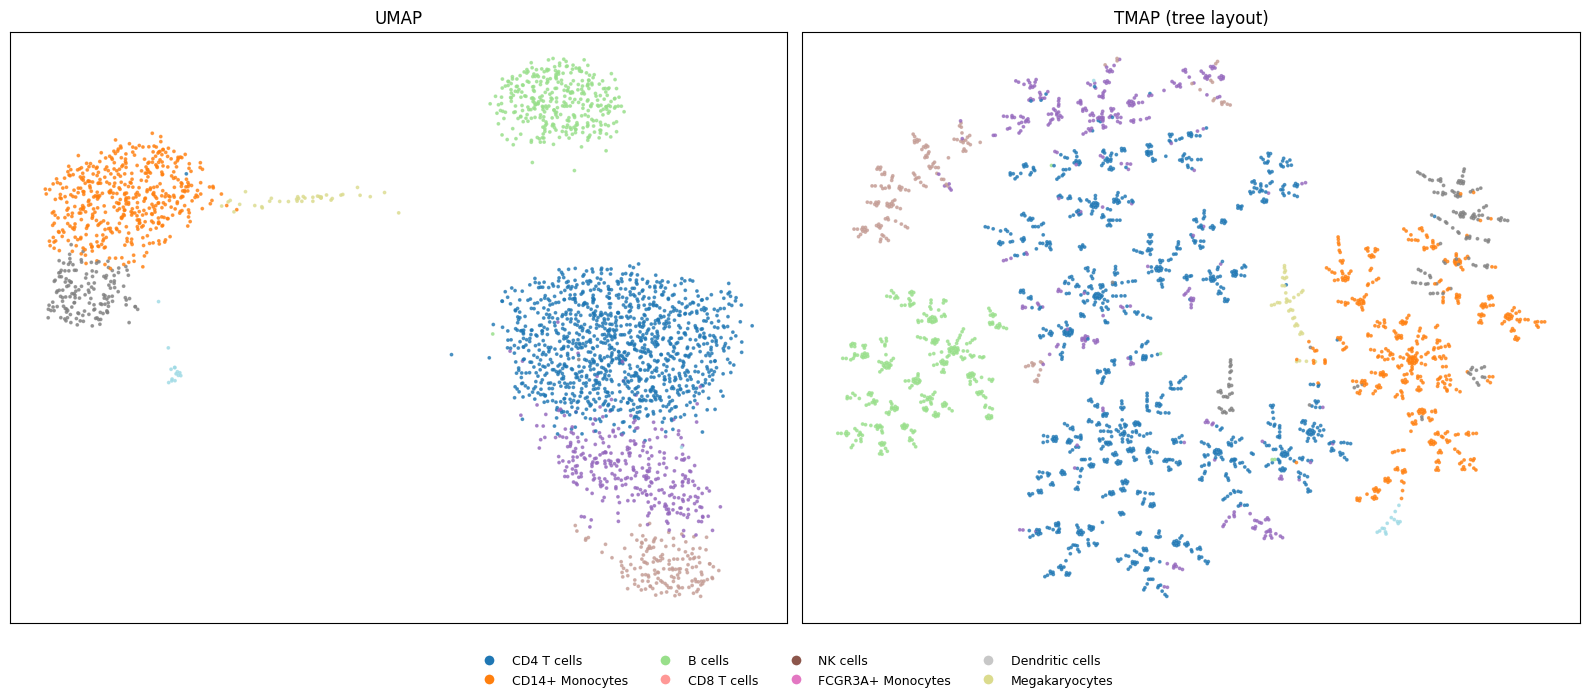

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cell_types = adata.obs["louvain"]
categories = cell_types.cat.categories
codes = cell_types.cat.codes.values
cmap = plt.cm.tab20

# UMAP (already in adata)
umap_coords = adata.obsm["X_umap"]
axes[0].scatter(umap_coords[:, 0], umap_coords[:, 1],
                c=codes, cmap=cmap, s=3, alpha=0.7)
axes[0].set_title("UMAP")
axes[0].set_xticks([])
axes[0].set_yticks([])

# TMAP
tmap_coords = model.embedding_
sc_tmap = axes[1].scatter(tmap_coords[:, 0], tmap_coords[:, 1],
                          c=codes, cmap=cmap, s=3, alpha=0.7)
axes[1].set_title("TMAP (tree layout)")
axes[1].set_xticks([])
axes[1].set_yticks([])

# Legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
                       markerfacecolor=cmap(i / len(categories)),
                       markersize=8, label=cat)
           for i, cat in enumerate(categories)]
fig.legend(handles=handles, loc="lower center", ncol=4,
           fontsize=9, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


In [ ]:
# """Enamine REAL TMAP — scalability test with chemistry utilities."""

import os
import time

import numpy as np

from tmap import TMAP
from tmap.layout import LayoutConfig
from tmap.utils.chemistry import fingerprints_from_smiles, molecular_properties

N = 40_000 
FP_BITS = 1024
FP_RADIUS = 2
DATA_PATH = "../data/20M_smiles.txt"


print(f"=== Enamine {N // 1_000_000}M TMAP ===\n")

# ------------------------------------------------------------------
# 1. Load SMILES
# ------------------------------------------------------------------
print(f"Loading {N:,} SMILES from {DATA_PATH}...")
t0 = time.time()

smiles: list[str] = []
with open(DATA_PATH) as f:
    for i, line in enumerate(f):
        if i >= N:
            break
        smiles.append(line.strip())

print(f"  Loaded {len(smiles):,} SMILES in {time.time() - t0:.1f}s\n")

# ------------------------------------------------------------------
# 2. Compute fingerprints
# ------------------------------------------------------------------
print(f"Computing Morgan fingerprints (radius={FP_RADIUS}, {FP_BITS} bits)...")
t0 = time.time()
fps = fingerprints_from_smiles(
    smiles, fp_type="morgan", radius=FP_RADIUS, n_bits=FP_BITS
)
print(f"  {fps.shape[0]:,} valid / {len(smiles):,} total in {time.time() - t0:.1f}s\n")

# ------------------------------------------------------------------
# 3. Compute molecular properties
# ------------------------------------------------------------------
print("Computing molecular properties (MW, LogP, NumRings)...")
t0 = time.time()
props = molecular_properties(smiles)
print(f"  Done in {time.time() - t0:.1f}s\n")

mw = props["mw"]
logp = props["logp"]
n_rings = props["n_rings"]

print(f"Fitting TMAP on {fps.shape[0]:,} fingerprints...")
t0 = time.time()

cfg = LayoutConfig()
cfg.node_size = 1 / 30
cfg.deterministic = True
cfg.seed = 42

model = TMAP(metric="jaccard", n_neighbors=20, n_permutations=512, kc=200, layout_config=cfg)
x, y, s, t_edges = model.fit_transform(fps)
print(f"  Layout done in {time.time() - t0:.1f}s\n")

# ------------------------------------------------------------------
# 5. Build visualization
# ------------------------------------------------------------------
print("Building TmapViz...")
t0 = time.time()
viz = model.to_tmapviz()
viz.title = f"Enamine_{N // 1_000_000}M"
viz.add_smiles(smiles)
viz.add_color_layout("MW", mw.tolist(), categorical=False, color="viridis")
viz.add_color_layout("LogP", logp.tolist(), categorical=False, color="plasma")

# NumRings as categorical (discrete integer values)
n_rings_str = [str(int(r)) if np.isfinite(r) else "?" for r in n_rings]
viz.add_color_layout("NumRings", n_rings_str, categorical=True, color="tab20")
print(f"  Built in {time.time() - t0:.1f}s\n")

# ------------------------------------------------------------------
# 6. Export + serve
# ------------------------------------------------------------------
print("Exporting HTML (binary mode)...")
t0 = time.time()
outpath = viz.write_html(f"examples/enamine_{N // 1_000_000}m_tmap.html", mode="binary")
fsize = os.path.getsize(outpath)
print(f"  Written to {outpath} ({fsize / 1e6:.1f} MB) in {time.time() - t0:.1f}s\n")

print("Starting serve mode on port 8052...")
print("Open http://127.0.0.1:8052")
print("Press Ctrl+C to stop.\n")
viz.serve(port=8052, open_browser=True)

In [ ]:
viz.title = '31fme.html'
viz.write_html('.')


PosixPath('31fme.html')